In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [30]:
df = pd.read_csv("AB_NYC_2019.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [32]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


In [33]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

print("Categorical Columns:")
print(categorical_columns.tolist())

for col in categorical_columns:
    print("\n", col)
    print(df[col].nunique(), "unique values")
    print(df[col].value_counts().head())

Categorical Columns:
['name', 'host_name', 'neighbourhood_group', 'neighbourhood', 'room_type', 'last_review']

 name
47905 unique values
name
Hillside Hotel                  18
Home away from home             17
New york Multi-unit building    16
Brooklyn Apartment              12
Private Room                    11
Name: count, dtype: int64

 host_name
11452 unique values
host_name
Michael         417
David           403
Sonder (NYC)    327
John            294
Alex            279
Name: count, dtype: int64

 neighbourhood_group
5 unique values
neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

 neighbourhood
221 unique values
neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
Name: count, dtype: int64

 room_type
3 unique values
room_type
Entire home/apt    25409
Private room     

In [34]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [35]:
missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values,
    "Missing Percentage": (
        missing_values.values / len(df) * 100
    ).round(2)
})

missing_table = missing_table[
    missing_table["Missing Values"] > 0
]

missing_table.sort_values(
    by="Missing Values",
    ascending=False
)

,Column,Missing Values,Missing Percentage
13,reviews_per_month,10052,20.56
12,last_review,10052,20.56
3,host_name,21,0.04
1,name,16,0.03


In [36]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64


In [37]:
columns_to_drop = [
    "id",
    "name",
    "host_id",
    "host_name",
    "last_review"
]

df = df.drop(
    columns=columns_to_drop
)

print("Columns after removal:")
print(df.columns.tolist())

print("\nNew shape:", df.shape)

Columns after removal:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

New shape: (48895, 11)


In [38]:
print(
    "Missing reviews_per_month before:",
    df["reviews_per_month"].isnull().sum()
)

median_reviews = df["reviews_per_month"].median()

df["reviews_per_month"] = (
    df["reviews_per_month"]
    .fillna(median_reviews)
)

print(
    "Missing reviews_per_month after:",
    df["reviews_per_month"].isnull().sum()
)

Missing reviews_per_month before: 10052
Missing reviews_per_month after: 0


In [40]:
print("Remaining missing values:")

print(
    df.isnull().sum()
    .sort_values(ascending=False)
    .head(10)
)

Remaining missing values:
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
dtype: int64


In [41]:
print("Price Statistics")
print("=================")

print("Minimum:", df["price"].min())
print("Maximum:", df["price"].max())
print("Mean:", df["price"].mean())
print("Median:", df["price"].median())

df["price"].describe()

Price Statistics
Minimum: 0
Maximum: 10000
Mean: 152.7206871868289
Median: 106.0


,price
count,48895.000000
mean,152.720687
std,240.154170
min,0.000000
25%,69.000000
50%,106.000000
75%,175.000000
max,10000.000000


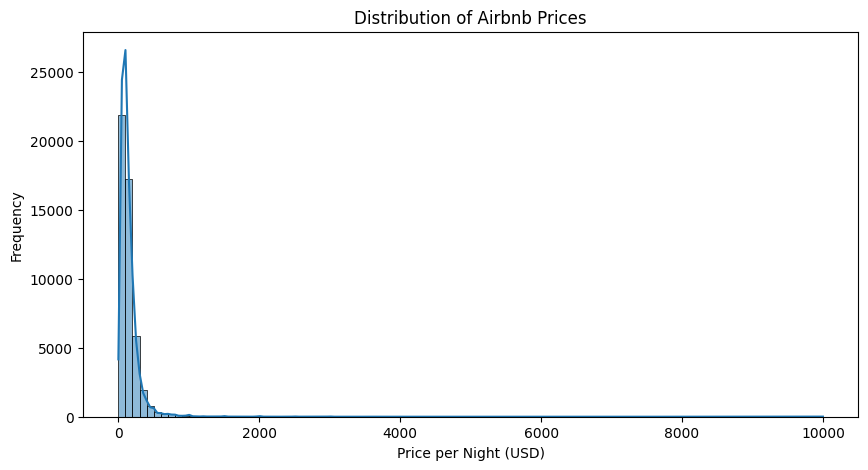

In [42]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["price"],
    bins=100,
    kde=True
)

plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price per Night (USD)")
plt.ylabel("Frequency")

plt.show()

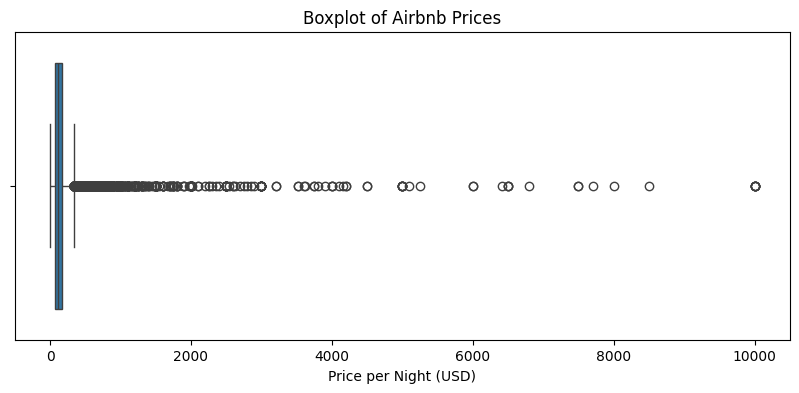

In [43]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df["price"]
)

plt.title("Boxplot of Airbnb Prices")
plt.xlabel("Price per Night (USD)")

plt.show()

In [44]:
zero_price_count = (
    df["price"] == 0
).sum()

print(
    "Number of listings with price = $0:",
    zero_price_count
)

Number of listings with price = $0: 11


In [45]:
df = df[df["price"] > 0].copy()

print(
    "Shape after removing zero-price listings:",
    df.shape
)

Shape after removing zero-price listings: (48884, 11)


In [46]:
price_99 = df["price"].quantile(0.99)

print("99th percentile of price:", price_99)
print("Maximum price:", df["price"].max())

99th percentile of price: 799.0
Maximum price: 10000


In [47]:
before = len(df)

df = df[
    df["price"] <= price_99
].copy()

after = len(df)

print("Rows before:", before)
print("Rows after:", after)
print("Rows removed:", before - after)

Rows before: 48884
Rows after: 48410
Rows removed: 474


count    48410.000000
mean       137.575170
std        103.780081
min         10.000000
25%         69.000000
50%        105.000000
75%        175.000000
max        799.000000
Name: price, dtype: float64


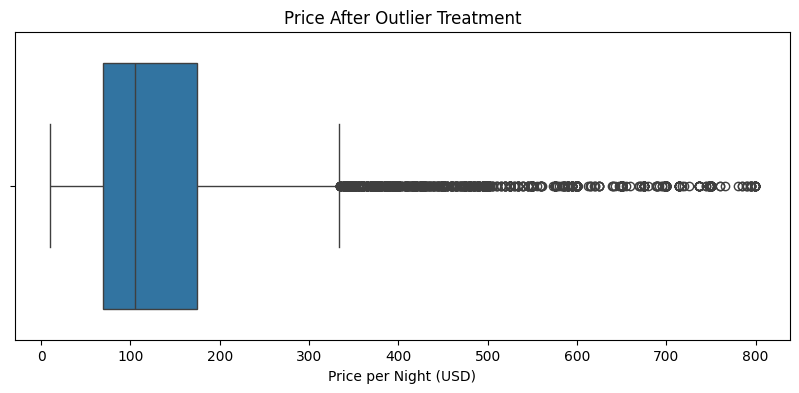

In [48]:
print(df["price"].describe())

plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df["price"]
)

plt.title("Price After Outlier Treatment")
plt.xlabel("Price per Night (USD)")

plt.show()

In [49]:
print(df["minimum_nights"].describe())

print(
    "\n99th percentile:",
    df["minimum_nights"].quantile(0.99)
)

print(
    "Maximum:",
    df["minimum_nights"].max()
)

count    48410.000000
mean         6.979508
std         20.293249
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1250.000000
Name: minimum_nights, dtype: float64

99th percentile: 40.0
Maximum: 1250


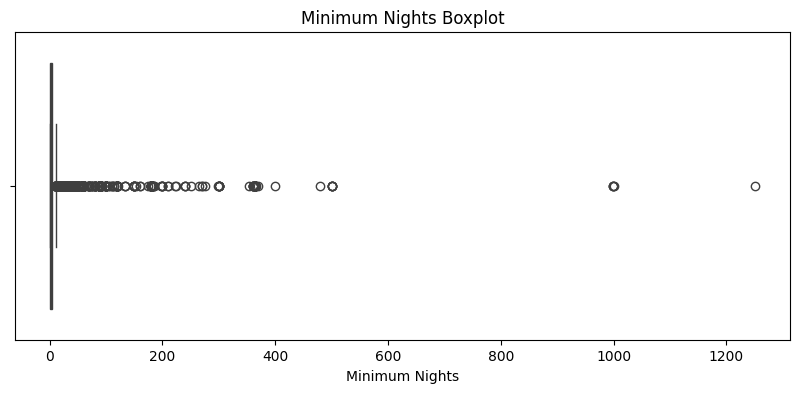

In [50]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df["minimum_nights"]
)

plt.title("Minimum Nights Boxplot")
plt.xlabel("Minimum Nights")

plt.show()

In [51]:
minimum_nights_99 = (
    df["minimum_nights"].quantile(0.99)
)

print(
    "99th percentile:",
    minimum_nights_99
)

df = df[
    df["minimum_nights"] <= minimum_nights_99
].copy()

print(
    "Maximum minimum_nights after treatment:",
    df["minimum_nights"].max()
)

99th percentile: 40.0
Maximum minimum_nights after treatment: 40


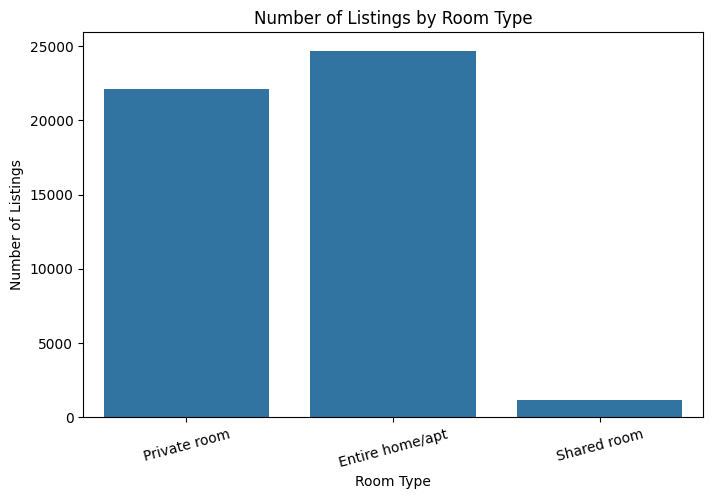

In [52]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="room_type"
)

plt.title("Number of Listings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")

plt.xticks(rotation=15)

plt.show()

room_type
Entire home/apt    189.491925
Private room        83.439408
Shared room         64.229148
Name: price, dtype: float64


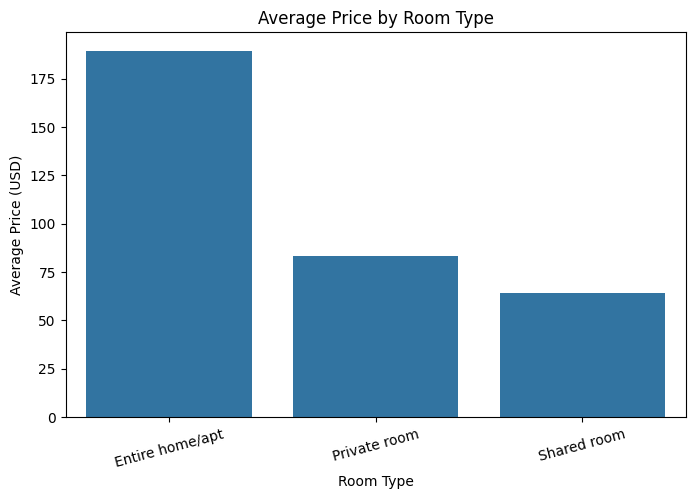

In [53]:
room_price = (
    df.groupby("room_type")["price"]
    .mean()
    .sort_values(ascending=False)
)

print(room_price)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=room_price.index,
    y=room_price.values
)

plt.title("Average Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Price (USD)")

plt.xticks(rotation=15)

plt.show()

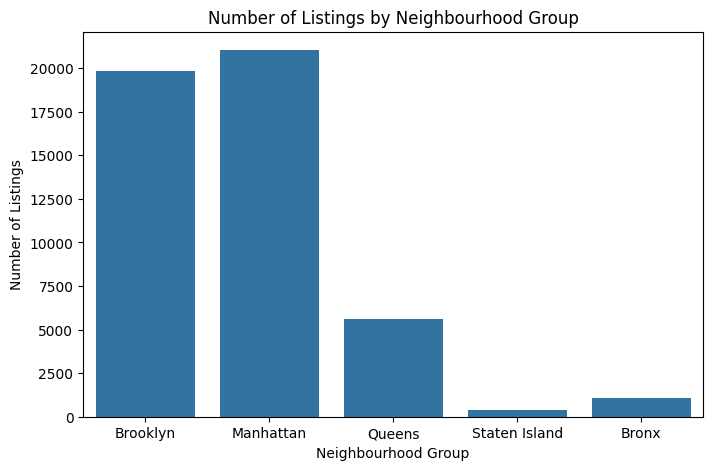

In [54]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="neighbourhood_group"
)

plt.title("Number of Listings by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Number of Listings")

plt.show()

neighbourhood_group
Manhattan        173.158898
Brooklyn         115.980828
Staten Island     94.225543
Queens            94.224595
Bronx             84.032558
Name: price, dtype: float64


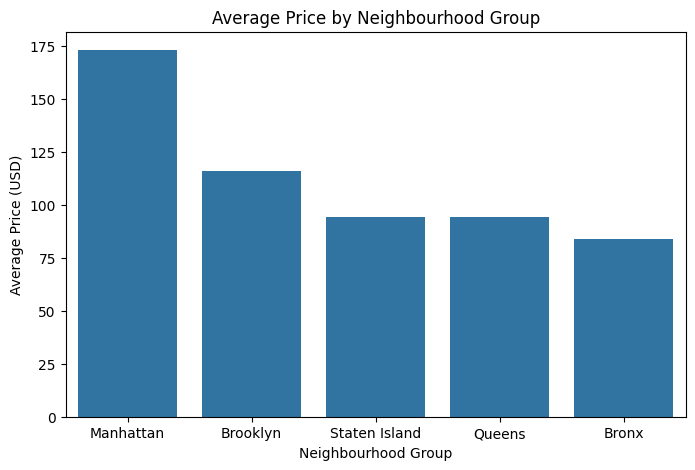

In [55]:
neighbourhood_price = (
    df.groupby("neighbourhood_group")["price"]
    .mean()
    .sort_values(ascending=False)
)

print(neighbourhood_price)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=neighbourhood_price.index,
    y=neighbourhood_price.values
)

plt.title("Average Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Average Price (USD)")

plt.show()

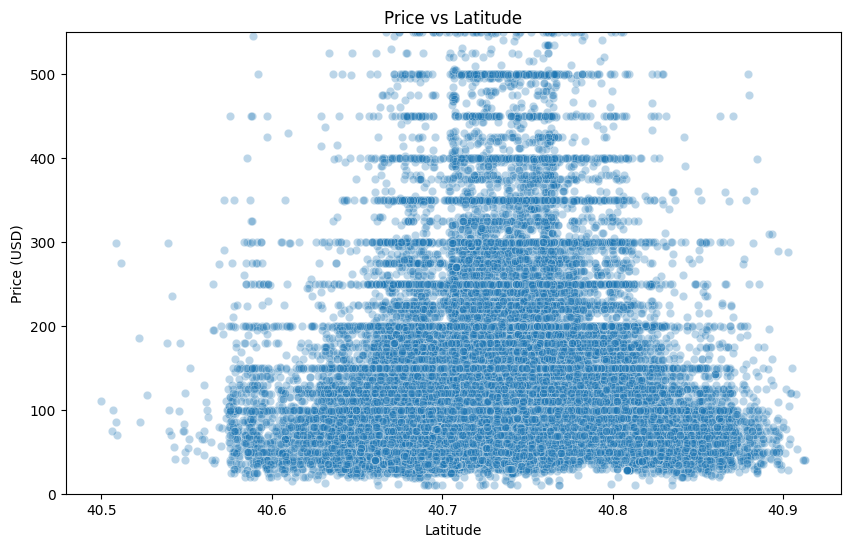

In [56]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="latitude",
    y="price",
    alpha=0.3
)

plt.title("Price vs Latitude")
plt.xlabel("Latitude")
plt.ylabel("Price (USD)")

plt.ylim(
    0,
    df["price"].quantile(0.99)
)

plt.show()

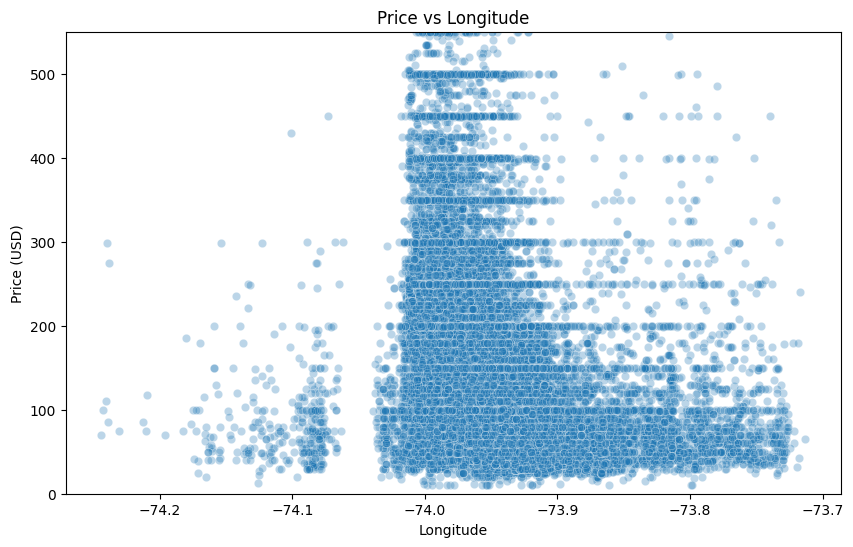

In [57]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="longitude",
    y="price",
    alpha=0.3
)

plt.title("Price vs Longitude")
plt.xlabel("Longitude")
plt.ylabel("Price (USD)")

plt.ylim(
    0,
    df["price"].quantile(0.99)
)

plt.show()

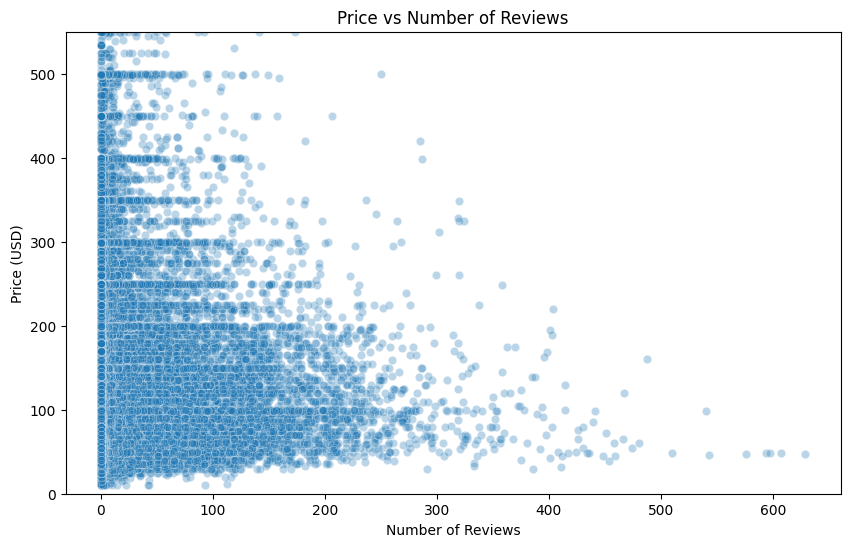

In [58]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="number_of_reviews",
    y="price",
    alpha=0.3
)

plt.title("Price vs Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Price (USD)")

plt.ylim(
    0,
    df["price"].quantile(0.99)
)

plt.show()

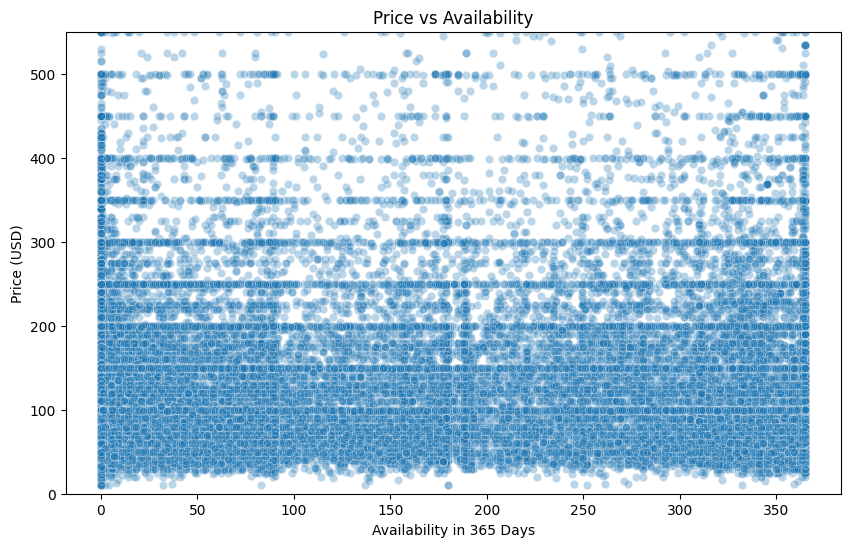

In [59]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="availability_365",
    y="price",
    alpha=0.3
)

plt.title("Price vs Availability")
plt.xlabel("Availability in 365 Days")
plt.ylabel("Price (USD)")

plt.ylim(
    0,
    df["price"].quantile(0.99)
)

plt.show()

In [60]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

correlation = df[
    numeric_columns
].corr()

correlation["price"].sort_values(
    ascending=False
)


,price
price,1.000000
calculated_host_listings_count,0.150252
availability_365,0.113405
latitude,0.067670
minimum_nights,0.054978
reviews_per_month,-0.039896
number_of_reviews,-0.056116
longitude,-0.273343


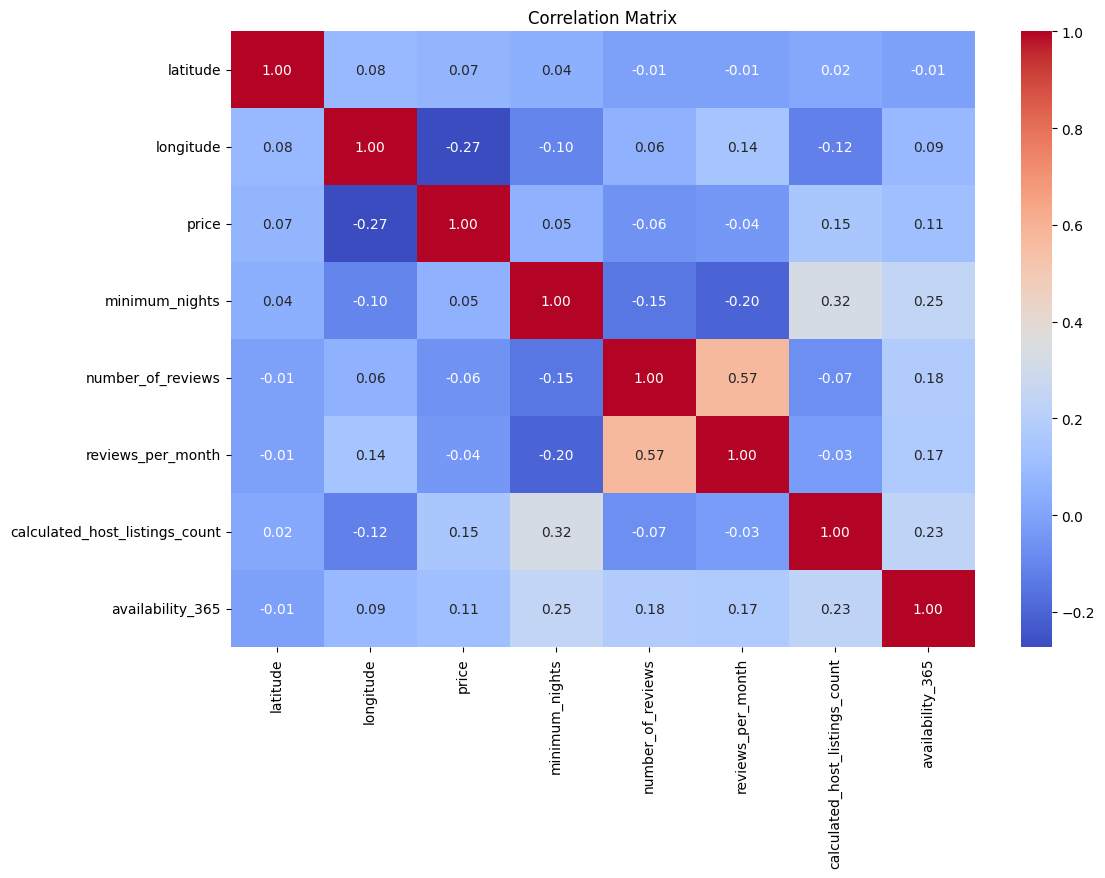

In [61]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [62]:
df["reviews_per_availability"] = (
    df["number_of_reviews"] /
    (df["availability_365"] + 1)
)

df["host_listing_density"] = (
    df["calculated_host_listings_count"] /
    (df["availability_365"] + 1)
)

print(
    df[
        [
            "reviews_per_availability",
            "host_listing_density"
        ]
    ].head()
)

   reviews_per_availability  host_listing_density
0                  0.024590              0.016393
1                  0.126404              0.005618
2                  0.000000              0.002732
3                  1.384615              0.005128
4                  9.000000              1.000000


In [63]:
df[
    [
        "reviews_per_availability",
        "host_listing_density"
    ]
].describe()

,reviews_per_availability,host_listing_density
count,47928.000000,47928.000000
mean,3.379484,0.596049
std,12.877205,2.784606
min,0.000000,0.002732
25%,0.009615,0.010989
50%,0.211652,0.062500
75%,2.000000,1.000000
max,480.000000,116.000000


In [64]:
features = [
    "neighbourhood_group",
    "neighbourhood",
    "latitude",
    "longitude",
    "room_type",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "reviews_per_availability",
    "host_listing_density"
]

target = "price"

X = df[features].copy()
y = df[target].copy()

print("Selected Features:")
for feature in features:
    print("-", feature)

print("\nTarget:", target)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Selected Features:
- neighbourhood_group
- neighbourhood
- latitude
- longitude
- room_type
- minimum_nights
- number_of_reviews
- reviews_per_month
- calculated_host_listings_count
- availability_365
- reviews_per_availability
- host_listing_density

Target: price

X shape: (47928, 12)
y shape: (47928,)


In [65]:
print("Missing values in selected features:")

print(
    X.isnull().sum()
)

Missing values in selected features:
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
reviews_per_availability          0
host_listing_density              0
dtype: int64


In [66]:
print("Final dataset shape:", df.shape)

print("\nFeatures used for prediction:")
print(features)

print("\nTarget variable:")
print(target)

Final dataset shape: (47928, 13)

Features used for prediction:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'reviews_per_availability', 'host_listing_density']

Target variable:
price


In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (38342, 12)
Testing data: (9586, 12)


In [69]:
numeric_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "reviews_per_availability",
    "host_listing_density"
]

categorical_features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [70]:
models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(
        alpha=10
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=150,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=4,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    )
}

In [71]:
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    mae = mean_absolute_error(y_test, test_pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, test_pred)
    )

    results.append({
        "Model": name,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Gap": train_r2 - test_r2
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Test R2",
    ascending=False
)

,Model,Train R2,Test R2,MAE,RMSE,R2 Gap
2,Random Forest,0.816855,0.504934,44.123514,72.603600,0.311921
3,Gradient Boosting,0.503380,0.484298,45.307729,74.101317,0.019082
1,Ridge Regression,0.417078,0.411109,49.667684,79.185180,0.005969
0,Linear Regression,0.418127,0.410092,49.762001,79.253546,0.008035


In [72]:
best_model_name = results_df.loc[
    results_df["Test R2"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [73]:
from sklearn.model_selection import RandomizedSearchCV

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        )
    )
])

param_grid = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [10, 15, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['latitude',
                                                                                'longitude',
                                                                                'minimum_nights',
                                                                                'number_of_reviews',
                                                                                'reviews_per_month',
                                                                                'calculated_host_listings_count',
                                                                                'availability_365',
                                                                                'reviews_per_availabi...
                                                                                'room_type'])])),
                                             ('model',
                                              RandomForestRegressor(n_jobs=-1,
                                                                    random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'model__max_depth': [10, 15, 20, None],
                                        'model__max_features': ['sqrt', 'log2',
                                                                0.5],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 150, 200]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [74]:
print("Best Hyperparameters:")
print(random_search.best_params_)

print(
    "\nBest Cross-Validation RMSE:",
    -random_search.best_score_
)

Best Hyperparameters:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': 15}

Best Cross-Validation RMSE: 73.65215935725764


In [75]:
final_model = random_search.best_estimator_

train_pred = final_model.predict(X_train)
test_pred = final_model.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

mae = mean_absolute_error(y_test, test_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, test_pred)
)

print("FINAL MODEL PERFORMANCE")
print("=======================")
print("Train R² :", round(train_r2, 4))
print("Test R²  :", round(test_r2, 4))
print("MAE      :", round(mae, 2))
print("RMSE     :", round(rmse, 2))

FINAL MODEL PERFORMANCE
Train R² : 0.7196
Test R²  : 0.5138
MAE      : 43.71
RMSE     : 71.95


In [76]:
r2_gap = train_r2 - test_r2

print("Train R²:", round(train_r2, 4))
print("Test R² :", round(test_r2, 4))
print("R² Gap  :", round(r2_gap, 4))

if train_r2 > 0.85 and r2_gap > 0.15:
    print("Result: Possible overfitting.")

elif train_r2 < 0.50 and test_r2 < 0.50:
    print("Result: Possible underfitting.")

elif r2_gap <= 0.08:
    print("Result: Good generalization with limited overfitting.")

else:
    print("Result: Some overfitting is present but acceptable.")

Train R²: 0.7196
Test R² : 0.5138
R² Gap  : 0.2057
Result: Some overfitting is present but acceptable.


In [77]:
final_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "Train R²",
        "Test R²",
        "R² Gap"
    ],
    "Final Model": [
        mae,
        rmse,
        train_r2,
        test_r2,
        r2_gap
    ]
})

final_results

,Metric,Final Model
0,MAE,43.714373
1,RMSE,71.947890
2,Train R²,0.719553
3,Test R²,0.513836
4,R² Gap,0.205718


In [78]:
import joblib

# Save the complete pipeline (preprocessing + trained model)
joblib.dump(random_search.best_estimator_, "airbnb_price_model.pkl")

print("Final model and preprocessing pipeline saved successfully!")
print("File: airbnb_price_model.pkl")

Final model and preprocessing pipeline saved successfully!
File: airbnb_price_model.pkl


In [79]:
# Load the saved pipeline
loaded_model = joblib.load("airbnb_price_model.pkl")

# Example new Airbnb listing
new_input = pd.DataFrame({
    "neighbourhood_group": ["Manhattan"],
    "neighbourhood": ["Midtown"],
    "latitude": [40.7549],
    "longitude": [-73.9840],
    "room_type": ["Entire home/apt"],
    "minimum_nights": [3],
    "number_of_reviews": [50],
    "reviews_per_month": [2.5],
    "calculated_host_listings_count": [2],
    "availability_365": [200],
    "reviews_per_availability": [50 / (200 + 1)],
    "host_listing_density": [2 / (200 + 1)]
})

# Predict price
predicted_price = loaded_model.predict(new_input)

print("Estimated Airbnb nightly price: $", round(predicted_price[0], 2))

Estimated Airbnb nightly price: $ 265.85


In [80]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 55.3 MB/s eta 0:00:00


In [81]:
import streamlit as st
import pandas as pd
import joblib

# Load trained model + preprocessing pipeline
model = joblib.load("airbnb_price_model.pkl")

# Page title
st.title("🏠 Airbnb Price Prediction")
st.write("Enter Airbnb listing details to estimate the nightly price.")

# Inputs
neighbourhood_group = st.selectbox(
    "Neighbourhood Group",
    ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"]
)

neighbourhood = st.text_input(
    "Neighbourhood",
    "Midtown"
)

latitude = st.number_input(
    "Latitude",
    value=40.7549,
    format="%.4f"
)

longitude = st.number_input(
    "Longitude",
    value=-73.9840,
    format="%.4f"
)

room_type = st.selectbox(
    "Room Type",
    ["Entire home/apt", "Private room", "Shared room"]
)

minimum_nights = st.number_input(
    "Minimum Nights",
    min_value=1,
    value=3
)

number_of_reviews = st.number_input(
    "Number of Reviews",
    min_value=0,
    value=50
)

reviews_per_month = st.number_input(
    "Reviews Per Month",
    min_value=0.0,
    value=2.5
)

calculated_host_listings_count = st.number_input(
    "Host Listings Count",
    min_value=1,
    value=2
)

availability_365 = st.number_input(
    "Availability (365 days)",
    min_value=0,
    max_value=365,
    value=200
)

# Button
if st.button("Predict Price"):

    # Feature engineering
    reviews_per_availability = (
        number_of_reviews / (availability_365 + 1)
    )

    host_listing_density = (
        calculated_host_listings_count / (availability_365 + 1)
    )

    # Create input dataframe
    new_input = pd.DataFrame({
        "neighbourhood_group": [neighbourhood_group],
        "neighbourhood": [neighbourhood],
        "latitude": [latitude],
        "longitude": [longitude],
        "room_type": [room_type],
        "minimum_nights": [minimum_nights],
        "number_of_reviews": [number_of_reviews],
        "reviews_per_month": [reviews_per_month],
        "calculated_host_listings_count": [
            calculated_host_listings_count
        ],
        "availability_365": [availability_365],
        "reviews_per_availability": [
            reviews_per_availability
        ],
        "host_listing_density": [
            host_listing_density
        ]
    })

    # Prediction
    prediction = model.predict(new_input)[0]

    # Display result
    st.success(
        f"Estimated Nightly Price: ${prediction:.2f}"
    )

2026-09-11 05:29:50.826 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 05:29:50.998 
  command:

    streamlit run /usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-09-11 05:29:50.999 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 05:29:51.000 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 05:29:51.001 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 05:29:51.002 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 05:29:51.003 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 05:29:51.005 Thread 'MainThread': mi

# Task 4 – Final Project Summary

## 1. Main Analysis

The Airbnb NYC 2019 dataset was used to develop a machine learning system for predicting the nightly price of an Airbnb listing. The dataset contains information about the location, room type, minimum nights, number of reviews, reviews per month, host listings, and availability.

During data preparation, duplicate records were removed and unnecessary identification columns such as listing ID, host ID, listing name, and host name were excluded. The `last_review` column was also removed because it was not directly used for prediction. Missing values in `reviews_per_month` were handled using median imputation.

Listings with zero price were removed because they do not represent valid nightly prices. Extreme values in `price` and `minimum_nights` were also handled using the 99th percentile to reduce the effect of extreme observations.

Exploratory data analysis showed that factors such as room type, neighbourhood, geographical location, minimum nights, availability, and host-related information can influence Airbnb prices.

Two additional features were created:

* `reviews_per_availability`
* `host_listing_density`

These features were added to provide additional information about listing activity and host listing density.

## 2. Model Comparison

Four regression models were considered:

* Linear Regression
* Ridge Regression
* Random Forest Regression
* Gradient Boosting Regression

The models were evaluated using:

* R² Score
* Mean Absolute Error (MAE)
* Root Mean Squared Error (RMSE)

R² was used to measure how well the model explains the variation in Airbnb prices. MAE measures the average absolute prediction error, while RMSE gives greater importance to larger errors.

The models were trained using the same training and testing data so that their performance could be compared fairly. Random Forest was further tuned using RandomizedSearchCV to find better hyperparameter combinations.

## 3. Final Model Performance

After comparing the models and tuning the Random Forest model, the final model was selected based on its test performance.

Final model:

**Random Forest Regressor with preprocessing and hyperparameter tuning**

Final Test Performance:

* **Training R² Score:** 0.719553
* **Test R² Score:** 0.513836
* **MAE:** 43.714373
* **RMSE:** 71.947890

The difference between training and testing R² was also checked to identify possible overfitting. The final model was saved as `airbnb_price_model.pkl` so that it could be reused in the application without retraining every time.

## 4. Application Results

A Streamlit web application was developed to make the trained model easier to use.

The application allows the user to enter Airbnb listing information such as:

* Neighbourhood Group
* Neighbourhood
* Latitude
* Longitude
* Room Type
* Minimum Nights
* Number of Reviews
* Reviews Per Month
* Host Listings Count
* Availability

The application automatically calculates the two engineered features required by the model:

* Reviews per Availability
* Host Listing Density

After the user clicks the prediction button, the trained model estimates the expected nightly Airbnb price.

The application provides the prediction in a simple format:

**Estimated Nightly Price: $XXX.XX**

The model and preprocessing pipeline were saved together so that the same preprocessing used during training is applied to new application inputs.

## 5. Important Limitations

Although the system provides useful price estimates, it has several limitations:

1. **Historical dataset:** The model is trained using the Airbnb NYC 2019 dataset, so it may not represent current Airbnb prices.

2. **Limited features:** Important factors such as property amenities, exact property quality, photographs, ratings, seasonal demand, and special events are not included.

3. **Geographical limitation:** The model was trained using New York City Airbnb data, so its predictions may not work well for other cities.

4. **Extreme prices:** Airbnb prices can contain unusual or luxury listings. Removing extreme values improves general prediction but means the model is less suitable for very expensive properties.

5. **Prediction is an estimate:** The application provides an estimated price and should not be treated as the exact market price.

6. **Neighbourhood input:** The prediction depends on the neighbourhood information entered by the user. An invalid or unfamiliar neighbourhood may reduce prediction reliability.

## 6. Overall Conclusion

The project successfully developed an end-to-end Airbnb price prediction system, starting from data analysis and preprocessing and ending with a working machine learning application. Exploratory analysis helped identify important patterns in Airbnb pricing, while feature engineering provided additional information for the regression models.

Several regression algorithms were compared, and the Random Forest model was selected and tuned to improve prediction performance. The final trained model was saved and integrated into a Streamlit application, allowing users to enter listing details and receive an estimated nightly price.

Overall, the project demonstrates how machine learning can be used to analyze Airbnb listing data and build a practical price prediction system. Future improvements could include using newer Airbnb data, adding more property and amenity features, incorporating seasonal information, and testing more advanced regression models.
